In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from itertools import groupby
# %matplotlib widget


In [2]:
# NOT PLOT RELATED, just function that loads sleeplab data:
def get_grass_start_end_time(starttime_raw, endtime_raw):
    
    time_str_elements = starttime_raw.flatten()
    start_time = ''.join(chr(time_str_elements[j]) for j in range(time_str_elements.shape[0]))
    time_str_elements = endtime_raw.flatten()
    end_time = ''.join(chr(time_str_elements[j]) for j in range(time_str_elements.shape[0]))

    start_time = start_time.split(':')
    second_elements = start_time[-1].split('.')
    start_time = datetime.datetime(1990,1,1,hour=int(float(start_time[0])), minute=int(float(start_time[1])),
        second=int(float(second_elements[0])), microsecond=int(float('0.'+second_elements[1])*1000000))
    end_time = end_time.split(':')
    second_elements = end_time[-1].split('.')
    end_time = datetime.datetime(1990,1,1,hour=int(float(end_time[0])), minute=int(float(end_time[1])),
        second=int(float(second_elements[0])), microsecond=int(float('0.'+second_elements[1])*1000000))

    return start_time, end_time

def check_load_mgh_dataset(data_path, label_path, channels=None, report_and_actual_time_tol=300, reverse_sign=False):

    gender = None
    handedness = None
    
    try: # usually Grass, saved as pre 7.3 format:
        ff = sio.loadmat(signalfilepath)
        data_path = os.path.basename(signalfilepath)
        if 's' not in ff:
            raise Exception('No signal found in %s.'%data_path)
        signal = ff['s']
        if reverse_sign:
            signal = -signal
        channel_names = [ff['hdr'][0,i]['signal_labels'][0].upper().replace('EKG','ECG') for i in range(ff['hdr'].shape[1])]
        gender = None
        handedness = None
        if 'grass' in signalfilepath:
            Fs = 200.
        else:
            raise Exception('Safety check to make sure this is Grass data with Fs=200')
        # Label part for grass:
        if 'grass' in signalfilepath:
            # load labels
            with h5py.File(labelfilepath) as ffl:
                sleep_stage = ffl['stage'][()].flatten()
                apnea = ffl['apnea'][()].flatten()
                start_time, end_time = get_grass_start_end_time(ffl['features']['StartTime'][()].flatten(), ffl['features']['EndTime'][()].flatten())


    except: # saved as .mat 7.3. new grass or natus files:
        with h5py.File(signalfilepath,'r') as ff:

            hdr = ff['hdr']
            signal_labels = hdr['signal_labels'][:]
            channel_names = [''.join(list(map(chr, ff[signal_labels[i,0]][:]))) for i in range(signal_labels.shape[0])]
            channel_names = [channel.upper() for channel in channel_names]
            signal = ff['s'][()]
            signal = np.transpose(signal);

            if 'recording' in ff.keys(): # only available for natus:
                year = int(np.squeeze(ff['recording']['year']))
                month = int(np.squeeze(ff['recording']['month']))
                day = int(np.squeeze(ff['recording']['day']))
                hour = int(np.squeeze(ff['recording']['hour']))
                if (hour >= 7) and (hour <=10):         # 'typo' by sleep techs
                    hour = hour + 12
                minute = int(np.squeeze(ff['recording']['minute']))
                second = int(np.squeeze(ff['recording']['second']))
                millisecond = int(np.squeeze(ff['recording']['millisecond']))
                Fs = int(np.squeeze(ff['recording']['samplingrate']))

                start_time = datetime.datetime(1990,1,1,hour=hour, minute=minute,
                        second=second, microsecond=int(millisecond*1000))
                end_time = start_time+datetime.timedelta(seconds=max(signal.shape)/Fs)

            else: # grass:
                if 'grass' in signalfilepath:
                    Fs = 200.
                else:
                    raise Exception('Safety check to make sure this is Grass data with Fs=200')

            # Label part for grass:
            ff.close()

        # load labels
        with h5py.File(labelfilepath) as ffl:
            sleep_stage = ffl['stage'][()].flatten()
            apnea = ffl['apnea'][()].flatten()
            if 'grass' in signalfilepath:
                start_time, end_time = get_grass_start_end_time(ffl['features']['StartTime'][()].flatten(), ffl['features']['EndTime'][()].flatten())
            ffl.close()

    # end of loading part
    ##################################
    
    # check signal length = sleep stage length
    if sleep_stage.shape[0]!=signal.shape[1]:
        raise Exception('Inconsistent sleep stage length (%d) and signal length (%d) in %s'%(sleep_stage.shape[0],signal.shape[1],data_path))

    # only take signal channels to study
    if channels is None:
        signal_channel_ids = list(range(len(channel_names)))
        
    elif 'SumEffort' in channels:
        signal_channel_ids = []
        signal_names = []
        for ichannel in ['ABD','CHEST']:
            #channel_name_pattern = re.compile(channels[i][:2].upper()+'-*'+channels[i][-2:].upper())
            found = False
            for j in range(len(channel_names)):
                if channel_names[j]==ichannel.upper():
                    signal_channel_ids.append(j)
                    signal_names.append(channel_names[j])
                    found = True
                    break
            if not found:
                raise Exception('Channel %s is not found.'%ichannel)
        signal = signal[signal_channel_ids,:]#.T
        # do effort belt average here:
        signal = np.sum(signal,0,keepdims=1)/2
        
    else:
        signal_channel_ids = []
        signal_names = []
        for i in range(len(channels)):
            #channel_name_pattern = re.compile(channels[i][:2].upper()+'-*'+channels[i][-2:].upper())
            found = False
            for j in range(len(channel_names)):
                if channel_names[j]==channels[i].upper():
                    signal_channel_ids.append(j)
                    signal_names.append(channel_names[j])
                    found = True
                    break
            if not found:
                continue
#                 raise Exception('Channel %s is not found.'%channels[i])
        signal = signal[signal_channel_ids,:]#.T

    # check whether the signal contains NaN
    if np.any(np.isnan(signal)):
        raise Exception('Found Nan in signal in %s'%data_path)

    # check whether sleep_stage contains all 5 stages
    stages = np.unique(sleep_stage[np.logical_not(np.isnan(sleep_stage))]).astype(int).tolist()
    if len(stages)<=1:
        if len(stages)==0:
            raise Exception('no sleep stages available in %s'%data_path)
        if stages[0] != 5: # only reasonable 1 sleepstage if all is Wake (==5), else raise Error
            raise Exception('#sleep stage <= 1: %s in %s'%(stages,data_path))

    params = {'Fs':Fs*1.0, 'signal_channel_ids':signal_channel_ids, 'signal_names':signal_names}
    if gender is not None:
        params['gender'] = gender
    if handedness is not None:
        params['handedness'] = handedness
    return signal, sleep_stage, apnea, params

In [3]:
def clip_z_normalize(signal):
    signal_clipped = np.clip(signal, np.percentile(signal,1), np.percentile(signal,99))
    signal = (signal - np.mean(signal_clipped))/np.std(signal_clipped)
    return signal


In [13]:
def multiple_lines_plot(trace, y, fs, normalize_signal=True, minutes_per_row=15, row_height=10):
    """
    Multi Line Plot
    Inputs:
    trace: 1D numpy array (if you want to plot multiple signals, this code needs to be modified)
    y: 1D label array
    fs: sampling frequency
    minutes_per_row: How many minutes of data shall be plotted in one line.
    row_height: heigt of each row for plots, experiment for best setting.
    
    Returns:
    matplotlib figure
    """

    minutes_data = trace.shape[0]/fs/60
    nrow = int(minutes_data/minutes_per_row)+1
    figsize = (24, int(nrow*1)) # automatic figsize, feel free to adapt.
    
    if normalize_signal:
        trace = (trace - np.median(trace)) / (np.quantile(trace, 0.75) - (np.quantile(trace, 0.25)))
    # split the full signal into chunks, later plot each chunk in one row
    row_ids = np.array_split(np.arange(len(trace)),nrow)
    row_ids.reverse()

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111)
    
    label_color = [None,'red','green','blue','magenta','cyan','orange']
    
    for ri in range(nrow):
        # SIGNAL PART
        ax.plot(trace[row_ids[ri]] + ri * row_height, c='k', lw=0.5)
        
        # plot annonation
        ax.axhline(ri * row_height - row_height//2, c=[0.5, 0.5, 0.5], ls='--', lw=0.2)  # gridline
        loc = 0
        # group all labels and plot them
        for i, j in groupby(y[row_ids[ri]]):
            len_j = len(list(j))
            if not np.isnan(i) and label_color[int(i)] is not None:
                # i is the value of the label
                # list(j) is the list of labels with same value
                ax.plot([loc, loc + len_j], [ri * row_height- row_height//2] * 2, c=label_color[int(i)],
                        lw=5) 
            loc += len_j
                        
    ax.axis('off')
    plt.tight_layout()
       
    return fig


In [19]:
# signal_type = 'artificial'
signal_type = 'real'


if signal_type == 'artificial':
    # artificial signal, 8 hours:
    fs = 10
    stepsize = 0.1
    trace = np.sin(np.arange(0, 8*fs*3600*stepsize, stepsize))
    trace = clip_z_normalize(trace)
    # random, artificial apnea labels:
    apnea = np.zeros(trace.shape)
    apnea[apnea.shape[0]//10 : apnea.shape[0]//10 +10*fs] = 1
    apnea[apnea.shape[0]//8 : apnea.shape[0]//8 +30*fs] = 1
    apnea[apnea.shape[0]//7 : apnea.shape[0]//7 +10*fs] = 1
    apnea[apnea.shape[0]//6 : apnea.shape[0]//6 +10*fs] = 1
    # if Apnea Prediction is binary, just leave it with 0/1. If there were more labels/categories, you use this code in the same way. Different color will be assigned to new category
    apnea[apnea.shape[0]//3 : apnea.shape[0]//3 +30*fs] = 2

elif signal_type == 'real':
    # load some real data
    
    import h5py
    import scipy.io as sio
    import datetime
    
    signalfilepath = '/media/mad3/Datasets_ConvertedData/sleeplab/grass_data/Abanur_Ismahan_022817_2139.000/Signal_Abanur_Ismahan_022817_2139.000.mat'
    labelfilepath = '/media/mad3/Datasets_ConvertedData/sleeplab/grass_data/Abanur_Ismahan_022817_2139.000/Labels_Abanur_Ismahan_022817_2139.000.mat'
    signal, sleep_stage, apnea, params = check_load_mgh_dataset(signalfilepath, labelfilepath, channels=['SAO2','SPO2','PTAF', 'CFlow', 'CHEST', 'ABD'], report_and_actual_time_tol=300, reverse_sign=False)

    data = pd.DataFrame()
    data['Apnea'] = apnea
    for iSignal, name in enumerate(params['signal_names']):
        data[name] = signal[iSignal]
    data.rename({'SAO2':'SPO2'}, axis=1, inplace=True)
    data['spo2'] = data['SPO2']
    fs = int(params['Fs'])

    # for example, let's plot ABD signal with apnea labels.
    trace = data['ABD'].values
    apnea = data['Apnea'].values

/home/wolfgang/anaconda3/envs/AirGoSleep/lib/python3.6/site-packages/ipykernel_launcher.py:85: H5pyDeprecationWarning: The default file mode will change to 'r' (read-only) in h5py 3.0. To suppress this warning, pass the mode you need to h5py.File(), or set the global default h5.get_config().default_file_mode, or set the environment variable H5PY_DEFAULT_READONLY=1. Available modes are: 'r', 'r+', 'w', 'w-'/'x', 'a'. See the docs for details.


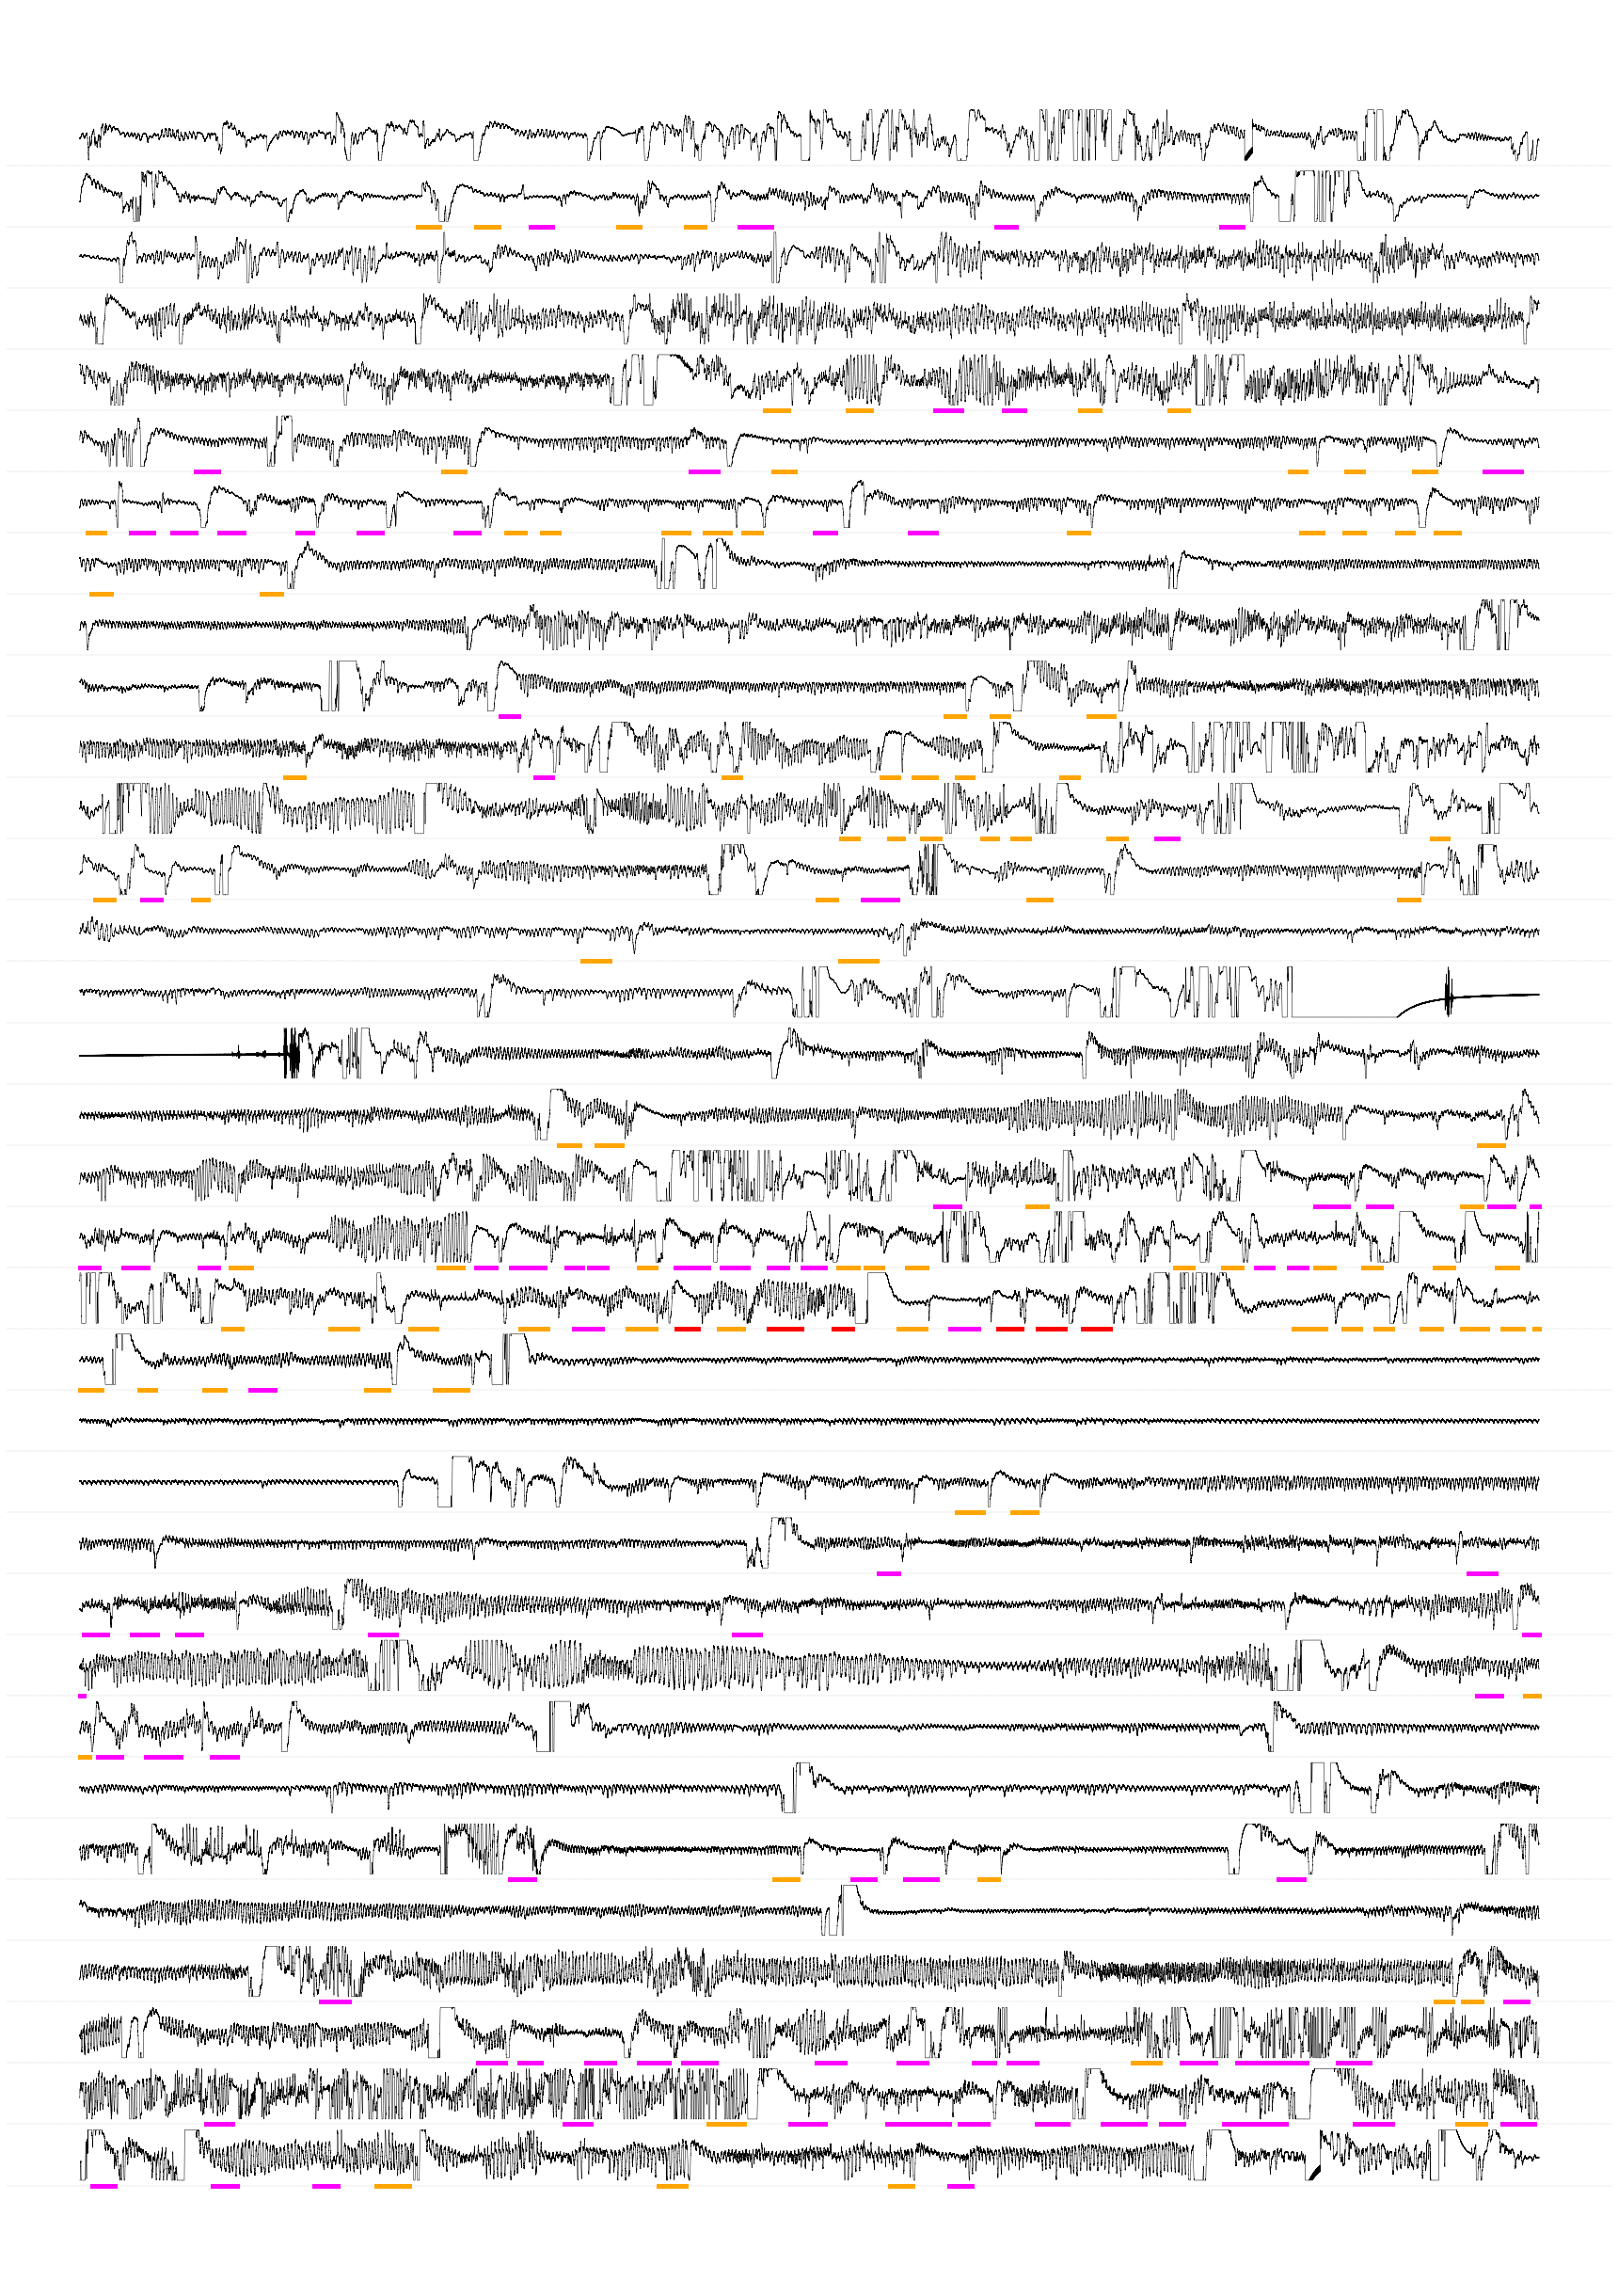

In [22]:
fig = multiple_lines_plot(trace, apnea, fs, row_height = 10)

In [24]:
fig.savefig('example_multilineplot.jpg')